  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN 

>>> 5 dòng đầu tiên của tập dữ liệu Chỉ số Kế toán:
    Ma_DN  X1_ThanhToanHienThoi  X2_TyLeNo    X3_ROA  X4_VongQuayTonKho  \
0  DN_001              2.051894   0.157646 -0.048719           4.212880   
1  DN_002              3.340888   0.713156 -0.085632           5.749597   
2  DN_003              2.796379   0.203367  0.198291           6.344409   
3  DN_004              1.347188   0.788131  0.125096           3.920486   
4  DN_005              1.163136   0.894573  0.002081           8.670997   

   Trang_Thai_KietQue  
0                   0  
1                   1  
2                   0  
3                   0  
4                   0  

----------------------------------------------------------------------
 TRƯỚC XỬ LÝ: Kiểm tra số lượng giá trị thiếu (Missing Values)
Ma_DN                    0
X1_ThanhToanHienThoi     0
X2_TyLeNo                0
X3_ROA                  12
X4_VongQuayTonKho        0
Trang_Thai_Kiet

C:\Users\Admin\AppData\Local\Temp\ipykernel_13308\27058995.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_accounting['X3_ROA'].fillna(roa_median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13308\27058995.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


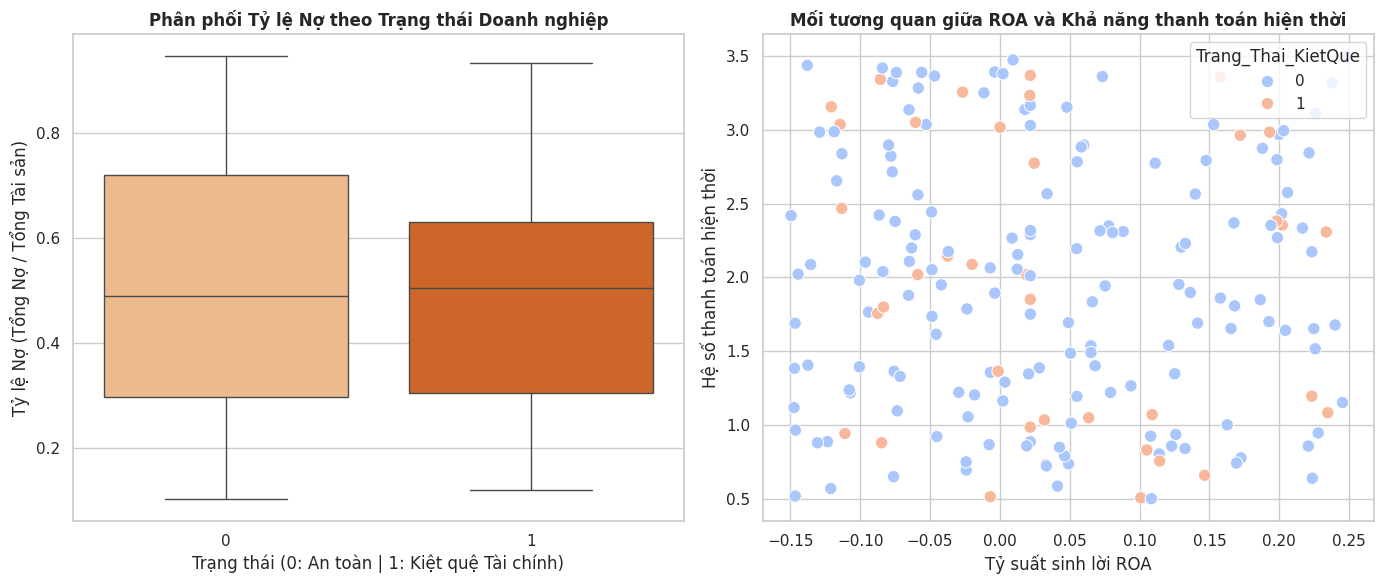


 CHẠY CODE CHỦ ĐỀ 2 THÀNH CÔNG RỰC RỠ! GRAPH ĐÃ ĐƯỢC HIỂN THỊ.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ họa để hiển thị mượt mà không lỗi font
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("======================================================================")
print("  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN ")
print("======================================================================")

# 1. KHỞI TẠO TẬP DỮ LIỆU CHỈ SỐ KẾ TOÁN (200 Doanh nghiệp)
np.random.seed(23)
n_companies = 200

accounting_data = {
    'Ma_DN': [f'DN_{i:03d}' for i in range(1, n_companies + 1)],
    
    # X1: Khả năng thanh toán hiện thời = Tài sản ngắn hạn / Nợ ngắn hạn
    'X1_ThanhToanHienThoi': np.random.uniform(0.5, 3.5, n_companies),
    
    # X2: Tỷ lệ Nợ = Tổng Nợ / Tổng Tài sản (Càng gần 1, nguy cơ phá sản càng cao)
    'X2_TyLeNo': np.random.uniform(0.1, 0.95, n_companies),
    
    # X3: Tỷ suất sinh lời của Tài sản (ROA) = Lợi nhuận sau thuế / Tổng Tài sản
    'X3_ROA': np.random.uniform(-0.15, 0.25, n_companies),
    
    # X4: Vòng quay hàng tồn kho = Giá vốn hàng bán / Hàng tồn kho bình quân
    'X4_VongQuayTonKho': np.random.uniform(1.5, 12.0, n_companies),
    
    # Trạng thái: 0 là Doanh nghiệp An toàn, 1 là Kiệt quệ tài chính (Nguy cơ phá sản)
    'Trang_Thai_KietQue': np.random.choice([0, 1], size=n_companies, p=[0.82, 0.18])
}

df_accounting = pd.DataFrame(accounting_data)

# Cố tình chèn dữ liệu trống (Null) vào cột ROA để làm sạch dữ liệu Kế toán
df_accounting.loc[np.random.choice(df_accounting.index, 12), 'X3_ROA'] = np.nan

print("\n>>> 5 dòng đầu tiên của tập dữ liệu Chỉ số Kế toán:")
print(df_accounting.head())


# 2. GIAI ĐOẠN TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
print("\n----------------------------------------------------------------------")
print(" TRƯỚC XỬ LÝ: Kiểm tra số lượng giá trị thiếu (Missing Values)")
print(df_accounting.isnull().sum())

# Điền giá trị trống của cột ROA bằng giá trị Trung vị (Median) của ngành
roa_median = df_accounting['X3_ROA'].median()
df_accounting['X3_ROA'].fillna(roa_median, inplace=True)

print("\n SAU XỬ LÝ: Kiểm tra lại số lượng giá trị thiếu:")
print(f"Số lỗi trống cột ROA còn lại: {df_accounting['X3_ROA'].isnull().sum()}")


# 3. GIAI ĐOẠN PHÂN TÍCH KHÁM PHÁ (EDA) & HIỂN THỊ GRAPH
print("\n----------------------------------------------------------------------")
print(">>> ĐANG KHỞI TẠO GRAPH PHÂN TÍCH KẾ TOÁN...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1: Biểu đồ hộp (Boxplot) so sánh Tỷ lệ Nợ (X2) giữa DN An toàn và DN Kiệt quệ
sns.boxplot(
    data=df_accounting, 
    x='Trang_Thai_KietQue', 
    y='X2_TyLeNo', 
    ax=axes[0], 
    palette='Oranges'
)
axes[0].set_title('Phân phối Tỷ lệ Nợ theo Trạng thái Doanh nghiệp', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trạng thái (0: An toàn | 1: Kiệt quệ Tài chính)')
axes[0].set_ylabel('Tỷ lệ Nợ (Tổng Nợ / Tổng Tài sản)')

# Graph 2: Biểu đồ phân tán (Scatter Plot) xem mối quan hệ giữa ROA (X3) và Khả năng thanh toán (X1)
sns.scatterplot(
    data=df_accounting, 
    x='X3_ROA', 
    y='X1_ThanhToanHienThoi', 
    hue='Trang_Thai_KietQue', 
    palette='coolwarm', 
    s=80, 
    ax=axes[1]
)
axes[1].set_title('Mối tương quan giữa ROA và Khả năng thanh toán hiện thời', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tỷ suất sinh lời ROA')
axes[1].set_ylabel('Hệ số thanh toán hiện thời')

plt.tight_layout()
plt.show()

print("\n======================================================================")
print(" CHẠY CODE CHỦ ĐỀ 2 THÀNH CÔNG RỰC RỠ! GRAPH ĐÃ ĐƯỢC HIỂN THỊ.")
print("======================================================================")

  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN 
Xử lý dữ liệu trống hoàn tất!
    Ma_DN  X1_ThanhToanHienThoi  X2_TyLeNo    X3_ROA  X4_VongQuayTonKho  \
0  DN_001              2.051894   0.157646 -0.048719           4.212880   
1  DN_002              3.340888   0.713156 -0.085632           5.749597   
2  DN_003              2.796379   0.203367  0.198291           6.344409   
3  DN_004              1.347188   0.788131  0.125096           3.920486   
4  DN_005              1.163136   0.894573  0.002081           8.670997   

   Trang_Thai_KietQue  
0                   0  
1                   1  
2                   0  
3                   0  
4                   0  


C:\Users\Admin\AppData\Local\Temp\ipykernel_13308\1223168302.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_accounting['X3_ROA'].fillna(roa_median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13308\1223168302.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_accounting, x='Trang_Thai_KietQue', y='X2_TyLeNo', ax=axes[0], palette='Oranges')
C:\Use

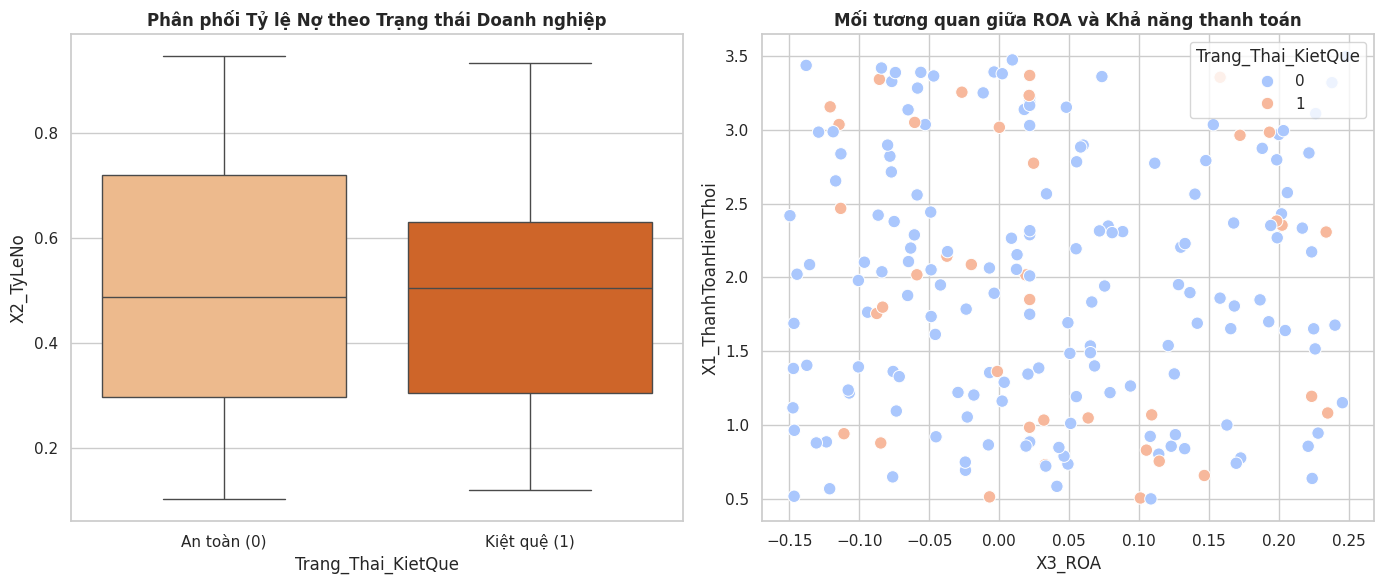

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ họa hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("======================================================================")
print("  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN ")
print("======================================================================")

# 1. KHỞI TẠO TẬP DỮ LIỆU CHỈ SỐ KẾ TOÁN (200 Doanh nghiệp)
np.random.seed(23)
n_companies = 200

accounting_data = {
    'Ma_DN': [f'DN_{i:03d}' for i in range(1, n_companies + 1)],
    'X1_ThanhToanHienThoi': np.random.uniform(0.5, 3.5, n_companies),
    'X2_TyLeNo': np.random.uniform(0.1, 0.95, n_companies),
    'X3_ROA': np.random.uniform(-0.15, 0.25, n_companies),
    'X4_VongQuayTonKho': np.random.uniform(1.5, 12.0, n_companies),
    'Trang_Thai_KietQue': np.random.choice([0, 1], size=n_companies, p=[0.82, 0.18])
}

df_accounting = pd.DataFrame(accounting_data)
df_accounting.loc[np.random.choice(df_accounting.index, 12), 'X3_ROA'] = np.nan

# 2. TIỀN XỬ LÝ DỮ LIỆU KẾ TOÁN
roa_median = df_accounting['X3_ROA'].median()
df_accounting['X3_ROA'].fillna(roa_median, inplace=True)

print("Xử lý dữ liệu trống hoàn tất!")
print(df_accounting.head())

# 3. VẼ GRAPH PHÂN TÍCH
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Đồ thị 1: Boxplot Tỷ lệ Nợ
sns.boxplot(data=df_accounting, x='Trang_Thai_KietQue', y='X2_TyLeNo', ax=axes[0], palette='Oranges')
axes[0].set_title('Phân phối Tỷ lệ Nợ theo Trạng thái Doanh nghiệp', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['An toàn (0)', 'Kiệt quệ (1)'])

# Đồ thị 2: Scatter Plot ROA vs Thanh Toán
sns.scatterplot(data=df_accounting, x='X3_ROA', y='X1_ThanhToanHienThoi', hue='Trang_Thai_KietQue', palette='coolwarm', s=80, ax=axes[1])
axes[1].set_title('Mối tương quan giữa ROA và Khả năng thanh toán', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()